# Task 3: Feature Engineering

## Objective

Create additional numerical and binary features from the restaurant dataset. The engineered file is the handoff for Level 3 modeling.

Required features:

- `Restaurant_Name_Length`
- `Address_Length`
- `Has_Table_Booking`
- `Has_Online_Delivery`

One extra feature is added because it is supported by the data and has a clear definition:

- `Cuisine_Count`

The original `Dataset.csv` is read only. New columns are added on a copy and exported to `data/engineered_dataset.csv`.


## Dataset Overview

Columns are classified after inspection, not by assumption.

Text fields used for derived features:

- `Restaurant Name`
- `Address`
- `Cuisines`

Categorical service fields encoded as binary flags:

- `Has Table booking`
- `Has Online delivery`


## Import Libraries


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.dpi"] = 120

BASE_DIR = Path.cwd()
DATA_PATH = (BASE_DIR / "../Dataset.csv").resolve()
FIG_DIR = BASE_DIR / "outputs" / "figures"
TAB_DIR = BASE_DIR / "outputs" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("Working directory:", BASE_DIR)
print("Dataset path:", DATA_PATH)

DATA_OUT = BASE_DIR / "data"
DATA_OUT.mkdir(parents=True, exist_ok=True)
ENGINEERED_PATH = DATA_OUT / "engineered_dataset.csv"


Working directory: C:\Users\adity\Documents\Cognifyz\Level-2\Task-3_Feature_Engineering
Dataset path: C:\Users\adity\Documents\Cognifyz\Level-2\Dataset.csv


## Load Dataset


In [2]:
df_raw = pd.read_csv(DATA_PATH)
shape_before = df_raw.shape

print("Shape before engineering:", shape_before)
print("Column names:")
print(list(df_raw.columns))
df_raw.head()


Shape before engineering: (9551, 21)
Column names:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## Data Validation


In [3]:
print("Data types:")
print(df_raw.dtypes)
print()
print("Missing values:")
print(df_raw.isna().sum())
print()
print("Duplicate rows:", int(df_raw.duplicated().sum()))
print()
print("Has Table booking values:", df_raw["Has Table booking"].unique().tolist())
print("Has Online delivery values:", df_raw["Has Online delivery"].unique().tolist())
print("Cuisines missing:", int(df_raw["Cuisines"].isna().sum()))


Data types:
Restaurant ID             int64
Restaurant Name             str
Country Code              int64
City                        str
Address                     str
Locality                    str
Locality Verbose            str
Longitude               float64
Latitude                float64
Cuisines                    str
Average Cost for two      int64
Currency                    str
Has Table booking           str
Has Online delivery         str
Is delivering now           str
Switch to order menu        str
Price range               int64
Aggregate rating        float64
Rating color                str
Rating text                 str
Votes                     int64
dtype: object

Missing values:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0

## Feature Inventory

Classification is based on the loaded schema.


In [4]:
numerical_cols = df_raw.select_dtypes(include=["number"]).columns.tolist()
text_like_cols = ["Restaurant Name", "Address", "Cuisines", "Locality", "Locality Verbose"]
categorical_cols = [
    c for c in df_raw.columns
    if c not in numerical_cols
]

inventory = pd.DataFrame({
    "Column": df_raw.columns,
    "Dtype": [str(t) for t in df_raw.dtypes],
    "Non_Null": df_raw.notna().sum().values,
    "Missing": df_raw.isna().sum().values,
    "Nunique": [df_raw[c].nunique(dropna=False) for c in df_raw.columns],
})
inventory["Class"] = inventory["Column"].apply(
    lambda c: "Numerical" if c in numerical_cols else ("Text" if c in text_like_cols else "Categorical")
)
inventory.to_csv(TAB_DIR / "feature_inventory.csv", index=False)
inventory


,Column,Dtype,Non_Null,Missing,Nunique,Class
0,Restaurant ID,int64,9551,0,9551,Numerical
1,Restaurant Name,str,9551,0,7446,Text
2,Country Code,int64,9551,0,15,Numerical
3,City,str,9551,0,141,Categorical
4,Address,str,9551,0,8918,Text
5,Locality,str,9551,0,1208,Text
6,Locality Verbose,str,9551,0,1265,Text
7,Longitude,float64,9551,0,8120,Numerical
8,Latitude,float64,9551,0,8677,Numerical
9,Cuisines,str,9542,9,1826,Text


## Feature Engineering

Definitions:

- `Restaurant_Name_Length` = number of characters in `Restaurant Name`
- `Address_Length` = number of characters in `Address`
- `Has_Table_Booking` = 1 if `Has Table booking` is Yes, else 0
- `Has_Online_Delivery` = 1 if `Has Online delivery` is Yes, else 0
- `Cuisine_Count` = number of comma-separated cuisine labels; 0 when `Cuisines` is missing

Original categorical columns are kept. Encoded columns are added beside them.


In [5]:
df = df_raw.copy()

df["Restaurant_Name_Length"] = df["Restaurant Name"].fillna("").astype(str).str.len()
df["Address_Length"] = df["Address"].fillna("").astype(str).str.len()

booking_map = {"Yes": 1, "No": 0}
delivery_map = {"Yes": 1, "No": 0}

unexpected_booking = set(df["Has Table booking"].dropna().unique()) - set(booking_map)
unexpected_delivery = set(df["Has Online delivery"].dropna().unique()) - set(delivery_map)
if unexpected_booking:
    raise ValueError(f"Unexpected Has Table booking values: {unexpected_booking}")
if unexpected_delivery:
    raise ValueError(f"Unexpected Has Online delivery values: {unexpected_delivery}")

df["Has_Table_Booking"] = df["Has Table booking"].map(booking_map).astype("int64")
df["Has_Online_Delivery"] = df["Has Online delivery"].map(delivery_map).astype("int64")

df["Cuisine_Count"] = (
    df["Cuisines"]
    .fillna("")
    .astype(str)
    .str.split(",")
    .apply(lambda parts: 0 if parts == [""] else len([p.strip() for p in parts if p.strip()]))
    .astype("int64")
)

new_features = [
    "Restaurant_Name_Length",
    "Address_Length",
    "Has_Table_Booking",
    "Has_Online_Delivery",
    "Cuisine_Count",
]
print("New features added:", new_features)
df[new_features].head()


New features added: ['Restaurant_Name_Length', 'Address_Length', 'Has_Table_Booking', 'Has_Online_Delivery', 'Cuisine_Count']


,Restaurant_Name_Length,Address_Length,Has_Table_Booking,Has_Online_Delivery,Cuisine_Count
0,16,71,1,0,3
1,16,67,1,0,1
2,22,56,1,0,4
3,4,70,0,0,2
4,11,64,1,0,2


## Feature Validation


In [6]:
shape_after = df.shape
print("Shape before:", shape_before)
print("Shape after:", shape_after)
print("Columns added:", shape_after[1] - shape_before[1])
print()
print("New feature dtypes:")
print(df[new_features].dtypes)
print()
print("Missing values in new features:")
print(df[new_features].isna().sum())
print()
print("Duplicate rows after engineering:", int(df.duplicated().sum()))
print()
print("Has_Table_Booking unique:", sorted(df["Has_Table_Booking"].unique().tolist()))
print("Has_Online_Delivery unique:", sorted(df["Has_Online_Delivery"].unique().tolist()))
print()
print("Length feature ranges:")
print(df[["Restaurant_Name_Length", "Address_Length", "Cuisine_Count"]].describe())

assert set(df["Has_Table_Booking"].unique()).issubset({0, 1})
assert set(df["Has_Online_Delivery"].unique()).issubset({0, 1})
assert df["Restaurant_Name_Length"].min() >= 0
assert df["Address_Length"].min() >= 0
assert df["Cuisine_Count"].min() >= 0
assert df[new_features].isna().sum().sum() == 0

# Encoding should match the original Yes/No columns.
assert (
    ((df["Has Table booking"] == "Yes") == (df["Has_Table_Booking"] == 1)).all()
)
assert (
    ((df["Has Online delivery"] == "Yes") == (df["Has_Online_Delivery"] == 1)).all()
)
print()
print("Validation checks passed.")


Shape before: (9551, 21)
Shape after: (9551, 26)
Columns added: 5

New feature dtypes:
Restaurant_Name_Length    int64
Address_Length            int64
Has_Table_Booking         int64
Has_Online_Delivery       int64
Cuisine_Count             int64
dtype: object

Missing values in new features:
Restaurant_Name_Length    0
Address_Length            0
Has_Table_Booking         0
Has_Online_Delivery       0
Cuisine_Count             0
dtype: int64

Duplicate rows after engineering: 0

Has_Table_Booking unique: [0, 1]
Has_Online_Delivery unique: [0, 1]

Length feature ranges:
       Restaurant_Name_Length  Address_Length  Cuisine_Count
count             9551.000000     9551.000000    9551.000000
mean                15.164171       53.536698       2.063658
std                  6.858392       17.122035       1.094072
min                  2.000000       13.000000       0.000000
25%                 10.000000       41.000000       1.000000
50%                 14.000000       52.000000       2.000

## Feature Dictionary


In [7]:
feature_dictionary = pd.DataFrame([
    {
        "Feature": "Restaurant_Name_Length",
        "Type": "Numerical",
        "Description": "Number of characters in Restaurant Name",
        "Reason": "Name length is a simple text-derived signal that may relate to branding style",
        "Leakage_risk": "None. Derived only from Restaurant Name.",
    },
    {
        "Feature": "Address_Length",
        "Type": "Numerical",
        "Description": "Number of characters in Address",
        "Reason": "Address verbosity can proxy location detail without parsing free text",
        "Leakage_risk": "None. Derived only from Address.",
    },
    {
        "Feature": "Has_Table_Booking",
        "Type": "Binary",
        "Description": "1 if Has Table booking is Yes, otherwise 0",
        "Reason": "Numeric encoding of a service flag for later modeling",
        "Leakage_risk": "None. Direct encoding of an existing column.",
    },
    {
        "Feature": "Has_Online_Delivery",
        "Type": "Binary",
        "Description": "1 if Has Online delivery is Yes, otherwise 0",
        "Reason": "Numeric encoding of a service flag for later modeling",
        "Leakage_risk": "None. Direct encoding of an existing column.",
    },
    {
        "Feature": "Cuisine_Count",
        "Type": "Numerical",
        "Description": "Count of comma-separated cuisines; 0 if Cuisines is missing",
        "Reason": "Turns a multi-label text field into a compact numeric feature",
        "Leakage_risk": "None. Derived only from Cuisines. Missing values mapped to 0.",
    },
])
feature_dictionary.to_csv(TAB_DIR / "feature_dictionary.csv", index=False)
feature_dictionary


,Feature,Type,Description,Reason,Leakage_risk
0,Restaurant_Name_Length,Numerical,Number of characters in Restaurant Name,Name length is a simple text-derived signal th...,None. Derived only from Restaurant Name.
1,Address_Length,Numerical,Number of characters in Address,Address verbosity can proxy location detail wi...,None. Derived only from Address.
2,Has_Table_Booking,Binary,"1 if Has Table booking is Yes, otherwise 0",Numeric encoding of a service flag for later m...,None. Direct encoding of an existing column.
3,Has_Online_Delivery,Binary,"1 if Has Online delivery is Yes, otherwise 0",Numeric encoding of a service flag for later m...,None. Direct encoding of an existing column.
4,Cuisine_Count,Numerical,Count of comma-separated cuisines; 0 if Cuisin...,Turns a multi-label text field into a compact ...,None. Derived only from Cuisines. Missing valu...


## Visualizations


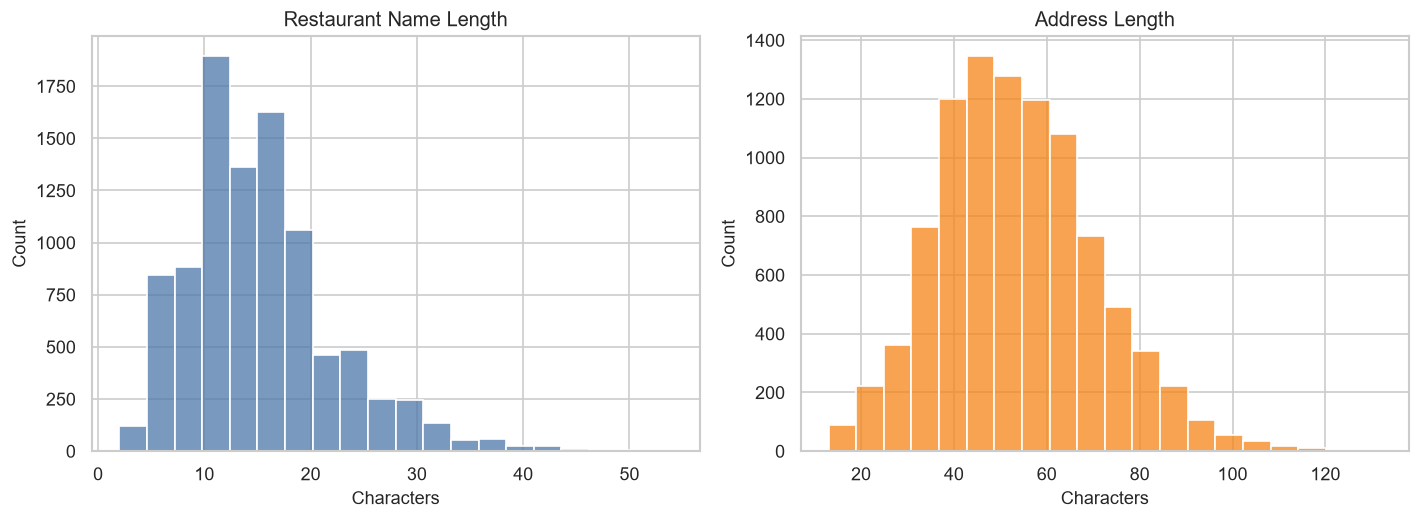

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df["Restaurant_Name_Length"], bins=20, color="#4C78A8", ax=axes[0])
axes[0].set_title("Restaurant Name Length")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Count")
sns.histplot(df["Address_Length"], bins=20, color="#F58518", ax=axes[1])
axes[1].set_title("Address Length")
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "text_length_distributions.png", dpi=300, bbox_inches="tight")
plt.show()


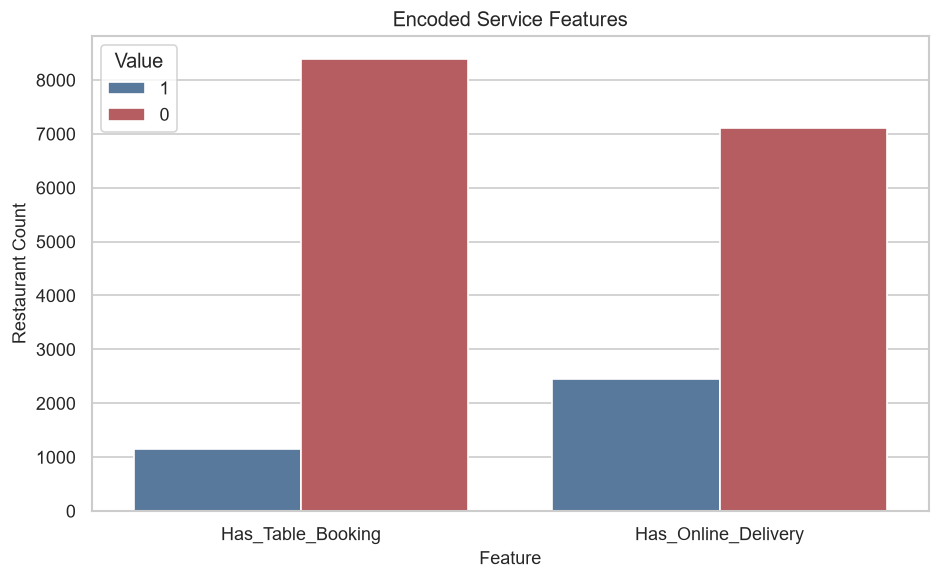

,Feature,Yes_Count,No_Count
0,Has_Table_Booking,1158,8393
1,Has_Online_Delivery,2451,7100


In [9]:
binary_summary = pd.DataFrame({
    "Feature": ["Has_Table_Booking", "Has_Online_Delivery"],
    "Yes_Count": [
        int((df["Has_Table_Booking"] == 1).sum()),
        int((df["Has_Online_Delivery"] == 1).sum()),
    ],
    "No_Count": [
        int((df["Has_Table_Booking"] == 0).sum()),
        int((df["Has_Online_Delivery"] == 0).sum()),
    ],
})
binary_summary.to_csv(TAB_DIR / "binary_feature_counts.csv", index=False)

plot_df = binary_summary.melt(
    id_vars="Feature",
    value_vars=["Yes_Count", "No_Count"],
    var_name="Class",
    value_name="Count",
)
plot_df["Class"] = plot_df["Class"].map({"Yes_Count": "1", "No_Count": "0"})

fig, ax = plt.subplots()
sns.barplot(
    data=plot_df,
    x="Feature",
    y="Count",
    hue="Class",
    palette={"1": "#4C78A8", "0": "#C44E52"},
    ax=ax,
)
ax.set_title("Encoded Service Features")
ax.set_xlabel("Feature")
ax.set_ylabel("Restaurant Count")
ax.legend(title="Value")
plt.tight_layout()
plt.savefig(FIG_DIR / "encoded_service_features.png", dpi=300, bbox_inches="tight")
plt.show()
binary_summary


## Export Engineered Dataset


In [10]:
df.to_csv(ENGINEERED_PATH, index=False)

check = pd.read_csv(ENGINEERED_PATH)
print("Exported:", ENGINEERED_PATH)
print("Reloaded shape:", check.shape)
print("Original Dataset.csv was not written to.")
print("New columns present:", all(col in check.columns for col in new_features))
assert check.shape == df.shape
assert all(col in check.columns for col in new_features)


Exported: C:\Users\adity\Documents\Cognifyz\Level-2\Task-3_Feature_Engineering\data\engineered_dataset.csv
Reloaded shape: (9551, 26)
Original Dataset.csv was not written to.
New columns present: True


## Results


In [11]:
print("Rows:", shape_after[0])
print("Columns before:", shape_before[1])
print("Columns after:", shape_after[1])
print()
print(df[new_features].describe().round(3).to_string())
print()
print("Has_Table_Booking = 1:", int((df["Has_Table_Booking"] == 1).sum()))
print("Has_Online_Delivery = 1:", int((df["Has_Online_Delivery"] == 1).sum()))
print("Cuisine_Count = 0 (missing or empty):", int((df["Cuisine_Count"] == 0).sum()))


Rows: 9551
Columns before: 21
Columns after: 26

       Restaurant_Name_Length  Address_Length  Has_Table_Booking  Has_Online_Delivery  Cuisine_Count
count                9551.000        9551.000           9551.000             9551.000       9551.000
mean                   15.164          53.537              0.121                0.257          2.064
std                     6.858          17.122              0.326                0.437          1.094
min                     2.000          13.000              0.000                0.000          0.000
25%                    10.000          41.000              0.000                0.000          1.000
50%                    14.000          52.000              0.000                0.000          2.000
75%                    19.000          64.000              0.000                1.000          3.000
max                    54.000         132.000              1.000                1.000          8.000

Has_Table_Booking = 1: 1158
Has_Online_De

## Findings


In [12]:
findings = f"""
1. Five features were added. The original 21 columns were retained.
2. Restaurant_Name_Length ranges from {int(df["Restaurant_Name_Length"].min())} to {int(df["Restaurant_Name_Length"].max())} characters.
3. Address_Length ranges from {int(df["Address_Length"].min())} to {int(df["Address_Length"].max())} characters.
4. Has_Table_Booking and Has_Online_Delivery are binary in {{0, 1}} and match the original Yes/No columns.
5. Cuisine_Count counts cuisine labels and is 0 for the {int((df["Cuisine_Count"] == 0).sum())} rows with missing or empty Cuisines.
6. The engineered file is saved at data/engineered_dataset.csv for Level 3.
"""
print(findings.strip())


1. Five features were added. The original 21 columns were retained.
2. Restaurant_Name_Length ranges from 2 to 54 characters.
3. Address_Length ranges from 13 to 132 characters.
4. Has_Table_Booking and Has_Online_Delivery are binary in {0, 1} and match the original Yes/No columns.
5. Cuisine_Count counts cuisine labels and is 0 for the 9 rows with missing or empty Cuisines.
6. The engineered file is saved at data/engineered_dataset.csv for Level 3.


## Conclusion

Feature engineering is limited to documented, leakage-free transformations. Binary encodings sit beside the original service columns. The exported CSV is the Level 2 handoff dataset.

Saved outputs:

- `data/engineered_dataset.csv`
- `outputs/tables/feature_dictionary.csv`
- `outputs/figures/`
